# Sonification Mapping: Vp to Pitch

This notebook begins the sonification stage of HelioSonic by defining a reusable framework for mapping normalized heliophysics data to auditory parameters. The goal is not to build the final sonification engine. The goal is to make mapping choices explicit, configurable, and scientifically inspectable before committing to audio design decisions.

Notebook 03 established the cleaning rules and first-pass normalization decisions for ACE SWEPAM variables. Those normalization decisions are treated here as upstream data-preparation choices. This notebook focuses only on what happens after a variable has already been normalized to a 0-1 range.

For this first mapping study, the scope is intentionally narrow: only solar wind speed, `Vp`, is mapped to pitch. `Np` and `Tpr` are left for later notebooks so the mapping framework can be evaluated one variable at a time.

## Design Principles

HelioSonic's current mapping is guided by the following principles:

- Preserve scientific relationships: higher or lower data values should have consistent auditory meaning unless an inversion is explicitly documented.
- Preserve temporal structure: gaps, cadence, and relative changes over time should not be hidden by the mapping process.
- Use perceptually distinguishable auditory dimensions: pitch, loudness, and timbre should be reserved for differences listeners can plausibly separate.
- Avoid misleading artifacts: mapping choices should not imply precision, continuity, or periodicity that is not present in the spacecraft data.
- Separate data processing from audio synthesis: cleaning, normalization, mapping, and sound generation should remain distinct steps.
- Prioritize interpretability over musicality: the first question is what the sound communicates about the measurement, not whether it sounds composed.

These are not the only possible sonification principles; they are the present design commitments for this research phase of HelioSonic.

## Load and Prepare Vp

The loading and cleaning logic below follows Notebook 03: CDF fill values and valid physical ranges are used to identify valid samples, invalid samples are preserved as `NaN`, and the original time axis is retained. For `Vp`, Notebook 03 selected min-max normalization as the first candidate for sonification because the variable is physically meaningful and bounded, while also noting that the observed speed range is narrow in this file.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import cdflib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

DATA_PATH = Path("../data/ac_h0_swe_20240709_v11.cdf")
VARIABLE = "Vp"
VARIABLE_LABEL = "Solar wind speed"

cdf = cdflib.CDF(DATA_PATH)
times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

print(f"Loaded: {DATA_PATH.name}")
print(f"Samples: {len(times)}")

Loaded: ac_h0_swe_20240709_v11.cdf
Samples: 1350


In [2]:
def clean_variable(cdf_file, variable_name, time_values):
    """Load one CDF variable and identify samples that are scientifically valid."""
    values = np.asarray(cdf_file.varget(variable_name), dtype=float)
    attrs = cdf_file.varattsget(variable_name)

    mask = np.isfinite(values)

    fill_value = attrs.get("FILLVAL")
    if fill_value is not None:
        mask &= values != fill_value

    valid_min = attrs.get("VALIDMIN")
    if valid_min is not None:
        mask &= values >= valid_min

    valid_max = attrs.get("VALIDMAX")
    if valid_max is not None:
        mask &= values <= valid_max

    return {
        "name": variable_name,
        "label": attrs.get("FIELDNAM", variable_name),
        "description": attrs.get("CATDESC", ""),
        "units": attrs.get("UNITS", ""),
        "values": values,
        "times": time_values,
        "mask": mask,
        "valid_values": values[mask],
        "attrs": attrs,
    }


def apply_mask_as_nan(values, mask):
    """Preserve the original time axis while marking invalid samples as NaN."""
    cleaned = np.asarray(values, dtype=float).copy()
    cleaned[~mask] = np.nan
    return cleaned


def min_max_normalize(values):
    """Normalize finite values to 0-1 while preserving NaN gaps."""
    values = np.asarray(values, dtype=float)
    finite_mask = np.isfinite(values)

    normalized = np.full_like(values, np.nan, dtype=float)
    if not np.any(finite_mask):
        return normalized

    data_min = np.nanmin(values)
    data_max = np.nanmax(values)

    if data_max == data_min:
        normalized[finite_mask] = 0.0
        return normalized

    normalized[finite_mask] = (values[finite_mask] - data_min) / (data_max - data_min)
    return normalized


vp_record = clean_variable(cdf, VARIABLE, times)
vp_record["nan_values"] = apply_mask_as_nan(vp_record["values"], vp_record["mask"])
vp_record["normalized"] = min_max_normalize(vp_record["nan_values"])

valid_count = int(np.sum(vp_record["mask"]))
invalid_count = len(vp_record["values"]) - valid_count

print(f"Variable: {VARIABLE} - {VARIABLE_LABEL}")
print(f"Units: {vp_record['units']}")
print(f"Valid samples: {valid_count}")
print(f"Invalid samples: {invalid_count} ({100 * invalid_count / len(vp_record['values']):.2f}%)")
print(f"Observed valid range: {np.nanmin(vp_record['nan_values']):.2f} to {np.nanmax(vp_record['nan_values']):.2f} {vp_record['units']}")

Variable: Vp - Solar wind speed
Units: km/s
Valid samples: 1257
Invalid samples: 93 (6.89%)
Observed valid range: 352.83 to 396.56 km/s


## Mapping Configuration

Mapping parameters are stored separately from the mapping function so scientific and perceptual assumptions can be changed without rewriting the mapping logic. The same structure can later be mirrored for amplitude, timbre, or spatial mappings.

In [3]:
@dataclass(frozen=True)
class PitchMappingConfig:
    """Parameters for mapping normalized data values to pitch in Hz."""

    min_frequency_hz: float = 220.0
    max_frequency_hz: float = 880.0
    scale: str = "log"
    invert: bool = False
    label: str = "220-880 Hz log"


mapping_configs = [
    PitchMappingConfig(220.0, 880.0, "linear", False, "220-880 Hz linear"),
    PitchMappingConfig(220.0, 880.0, "log", False, "220-880 Hz log"),
    PitchMappingConfig(300.0, 600.0, "log", False, "300-600 Hz log narrow"),
    PitchMappingConfig(220.0, 880.0, "log", True, "220-880 Hz log inverted"),
]

mapping_configs

[PitchMappingConfig(min_frequency_hz=220.0, max_frequency_hz=880.0, scale='linear', invert=False, label='220-880 Hz linear'),
 PitchMappingConfig(min_frequency_hz=220.0, max_frequency_hz=880.0, scale='log', invert=False, label='220-880 Hz log'),
 PitchMappingConfig(min_frequency_hz=300.0, max_frequency_hz=600.0, scale='log', invert=False, label='300-600 Hz log narrow'),
 PitchMappingConfig(min_frequency_hz=220.0, max_frequency_hz=880.0, scale='log', invert=True, label='220-880 Hz log inverted')]

## Mapping Function

The pitch mapping function accepts normalized values and returns frequency values in Hz. It preserves `NaN` samples so later synthesis can represent invalid or missing spacecraft samples as silence rather than interpolated pitch.

In [4]:
def normalized_to_pitch(normalized_values, config):
    """Map normalized 0-1 values to pitch frequencies in Hz.

    Parameters
    ----------
    normalized_values : array-like
        Values expected to be normalized to the inclusive 0-1 range. NaN values
        are preserved as NaN so invalid data intervals remain explicit.
    config : PitchMappingConfig
        Mapping parameters controlling frequency range, scale type, and inversion.

    Returns
    -------
    numpy.ndarray
        Pitch frequencies in Hz, with NaN values preserved.

    Raises
    ------
    TypeError
        If config is not a PitchMappingConfig.
    ValueError
        If frequencies are invalid, the scale is unsupported, or finite input
        values fall outside the 0-1 normalized range.
    """
    if not isinstance(config, PitchMappingConfig):
        raise TypeError("config must be a PitchMappingConfig")

    if config.min_frequency_hz <= 0 or config.max_frequency_hz <= 0:
        raise ValueError("Frequencies must be positive for pitch mapping")

    if config.max_frequency_hz <= config.min_frequency_hz:
        raise ValueError("max_frequency_hz must be greater than min_frequency_hz")

    if config.scale not in {"linear", "log"}:
        raise ValueError("scale must be either 'linear' or 'log'")

    values = np.asarray(normalized_values, dtype=float)
    finite_mask = np.isfinite(values)

    if np.any((values[finite_mask] < 0) | (values[finite_mask] > 1)):
        raise ValueError("Finite normalized values must be between 0 and 1")

    mapped_position = values.copy()
    if config.invert:
        mapped_position[finite_mask] = 1.0 - mapped_position[finite_mask]

    pitch = np.full_like(values, np.nan, dtype=float)

    if config.scale == "linear":
        pitch[finite_mask] = (
            config.min_frequency_hz
            + mapped_position[finite_mask]
            * (config.max_frequency_hz - config.min_frequency_hz)
        )
    else:
        frequency_ratio = config.max_frequency_hz / config.min_frequency_hz
        pitch[finite_mask] = config.min_frequency_hz * (
            frequency_ratio ** mapped_position[finite_mask]
        )

    return pitch


pitch_mappings = {
    config.label: normalized_to_pitch(vp_record["normalized"], config)
    for config in mapping_configs
}

## Mapping Visualization

These plots compare normalized `Vp` with pitch values produced by different mapping configurations. The purpose is to inspect the mapping behavior before generating audio: a configuration that looks clear in normalized space may be too compressed, too exaggerated, or too directionally confusing when expressed as frequency.

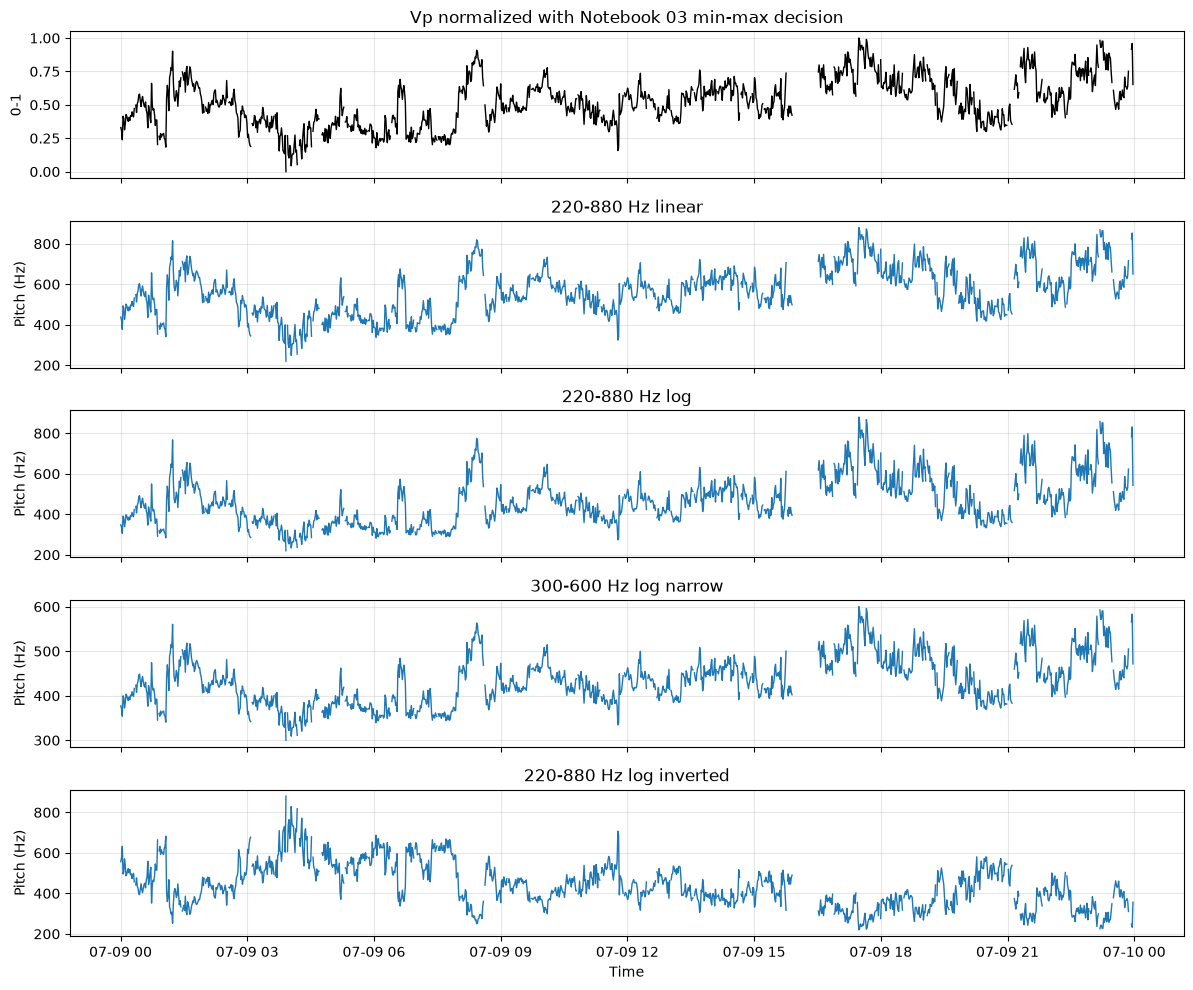

In [5]:
fig, axes = plt.subplots(len(mapping_configs) + 1, 1, figsize=(12, 10), sharex=True)

axes[0].plot(vp_record["times"], vp_record["normalized"], linewidth=1, color="black")
axes[0].set_title("Vp normalized with Notebook 03 min-max decision")
axes[0].set_ylabel("0-1")
axes[0].grid(alpha=0.3)

for axis, config in zip(axes[1:], mapping_configs):
    axis.plot(vp_record["times"], pitch_mappings[config.label], linewidth=1)
    axis.set_title(config.label)
    axis.set_ylabel("Pitch (Hz)")
    axis.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

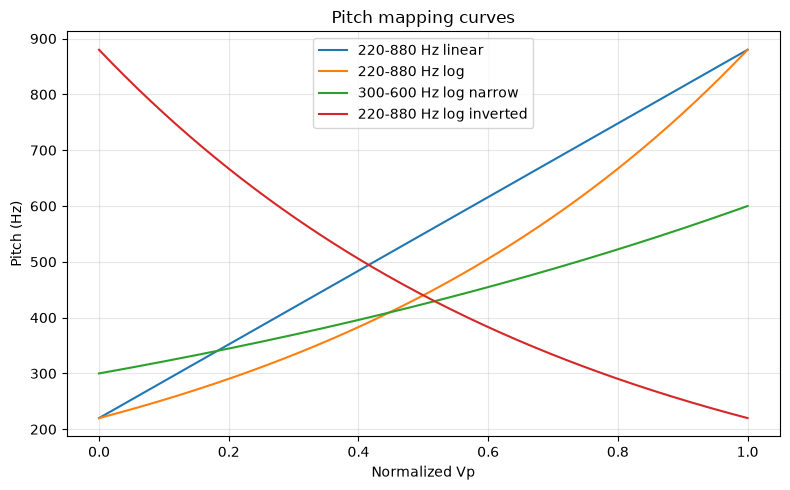

In [6]:
fig, axis = plt.subplots(figsize=(8, 5))
normalized_grid = np.linspace(0, 1, 200)

for config in mapping_configs:
    axis.plot(normalized_grid, normalized_to_pitch(normalized_grid, config), label=config.label)

axis.set_title("Pitch mapping curves")
axis.set_xlabel("Normalized Vp")
axis.set_ylabel("Pitch (Hz)")
axis.grid(alpha=0.3)
axis.legend()
plt.tight_layout()
plt.show()

## First Audio Prototype

The prototype below uses a single sine wave so the mapping can be heard without added musical interpretation. Invalid `Vp` samples become silence. No chords, reverb, envelopes, or layered oscillators are added.

The audio duration is short on purpose. These examples are meant for comparing mapping choices, not for presenting a finished sonification.

In [7]:
def synthesize_sine_from_pitch(
    pitch_hz,
    sample_rate=22050,
    output_duration_seconds=12.0,
    amplitude=0.2,
):
    """Generate a plain sine-wave prototype from a pitch trace.

    NaN pitch samples are rendered as silence. The oscillator phase is continuous
    across valid samples so changes in pitch reflect the mapping rather than
    artificial resets at each data point.
    """
    pitch_hz = np.asarray(pitch_hz, dtype=float)

    if sample_rate <= 0:
        raise ValueError("sample_rate must be positive")
    if output_duration_seconds <= 0:
        raise ValueError("output_duration_seconds must be positive")
    if amplitude < 0 or amplitude > 1:
        raise ValueError("amplitude must be between 0 and 1")

    output_sample_count = int(sample_rate * output_duration_seconds)
    source_positions = np.linspace(0, len(pitch_hz) - 1, output_sample_count)
    source_indices = np.rint(source_positions).astype(int)
    instantaneous_pitch = pitch_hz[source_indices]

    valid_pitch = np.isfinite(instantaneous_pitch)
    safe_pitch = np.where(valid_pitch, instantaneous_pitch, 0.0)

    phase = 2 * np.pi * np.cumsum(safe_pitch) / sample_rate
    audio = amplitude * np.sin(phase)
    audio[~valid_pitch] = 0.0

    return audio


prototype_audio = {
    config.label: synthesize_sine_from_pitch(pitch_mappings[config.label])
    for config in mapping_configs
}

In [8]:
for label, audio in prototype_audio.items():
    print(label)
    display(Audio(audio, rate=22050))

220-880 Hz linear


220-880 Hz log


300-600 Hz log narrow


220-880 Hz log inverted


## Observations

# Initial Listen
- 220-880 Hz linear: Initial listen there is a slight pitch variation (sounds a little wobbly which is to be expected) a slight noticable jump at around the 7-8 second mark. i think that if there were to actually be data analysis done here we'd need to slow down the speed at which we are running through the data since its quite hard to notice any standout features - the largest gap i noticed was barely a second long. through my headphones i can hear sort of pop sounds or sounds where the gain peaks it sounds a bit buzzy not sure why 

- 220-880 Hz log there was a bigger difference in pitch i could hear it was different than linear. the notes sounded lower but the gap was at the same place around the 7 second mark. similar comments to first recording 

- 300-600 Hz log narrow sounds the most like real-life wind. this hsa the smallest range and its noticable... i cant really hear much variation in the pitch. again gap around 7 second and has the same issue of sounding a bit busy (im guessing the small gaps in between some of the data has something to do with it) 

- 220-800 Hz log inverted like the name is like the second recording but with an inverted sound, the lower pitches came later in the audio clip rather than earlier


# Feedback

Across all four mappings, the 12 second playback was too fast to support detailed interpretation. Listeners could identify the major missing-data interval near the seven second mark and broad pitch-direction differences, but the signal sounded buzzy and difficult to interpret as structured data. The narrow logarithmic mapping was more comfortable but reduced audible variation. Audible pops and roughness likely arose from abrupt pitch updates and transitions into and out of missing-data gaps. Most likely the playback will have to be slowed and the auditory control signal smoothed or interpolated. 